# Where we are

**The one question this whole project has become:** AVES — a model trained on *general* animal
audio — beats our model trained specifically on zebra finches. **Why?** If we can name the reason,
we know how to build something better than AVES.

We've been working through the suspects one at a time. Four sections, each short:

1. **The scoreboard** — who's winning, and is the gap real?
2. **The suspects** — every explanation we've tested, and what's been ruled out
3. **The biggest clue** — the one suspect we've never tested
4. **What's next** — who does what

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

A = Path.home() / "zf_labelset/zf_detection_dataset_v1/analysis"
VAR   = json.loads((A / "aves_variants_calltype.json").read_text())   # run11 + six AVES checkpoints
R15   = json.loads((A / "run15_calltype.json").read_text())           # run15 on the same probe
BOOT  = json.loads((A / "run15_bootstrap.json").read_text())          # paired intervals vs run15
COMP  = json.loads((A / "compute_budget.json").read_text())           # run11 + AVES training budgets
COMP15 = json.loads((A / "run15_compute.json").read_text())           # run15 measured, run16 projected

# two roles only, validated with the dataviz palette checker (CVD dE 24.7, contrast >= 3:1)
OURS, AVES = "#eb6834", "#2a78d6"
INK, INK2, SURFACE, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e6e5e0"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
                     "axes.edgecolor": GRID, "axes.labelcolor": INK2, "xtick.color": INK2,
                     "ytick.color": INK, "text.color": INK, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
print("loaded 5 result files")

loaded 5 result files


---
## 1. The scoreboard

Task: tell apart **11 zebra finch call types**. We freeze each model, read out its internal
representation, and train only a simple classifier on top. Tested on birds the classifier never
saw during training. Higher is better.

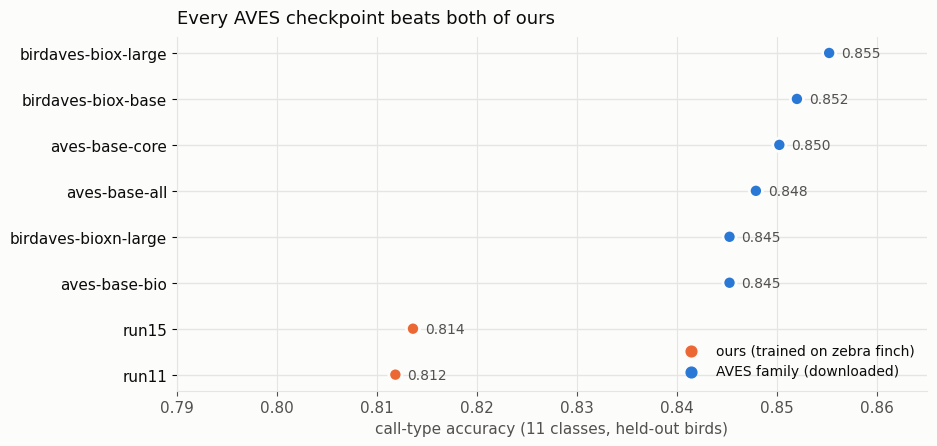

In [2]:
acc = {m: VAR["models"][m]["best_11"]["acc"] for m in VAR["models"]}
acc["run15"] = R15["acc11"]
ours = {"run11", "run15"}
order = sorted(acc, key=acc.get)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
y = np.arange(len(order))
# full-width row guides, NOT stems: the axis starts at 0.79, so a stem from there would read
# as a bar length and exaggerate the gap. Only the dot position carries meaning.
ax.hlines(y, 0.79, 0.865, color=GRID, lw=1, zorder=1)
ax.scatter([acc[m] for m in order], y, s=90, zorder=3,
           color=[OURS if m in ours else AVES for m in order],
           edgecolors=SURFACE, linewidths=2)
for yi, m in zip(y, order):
    ax.text(acc[m] + 0.0012, yi, f"{acc[m]:.3f}", va="center", fontsize=10, color=INK2)
ax.set_yticks(y); ax.set_yticklabels(order)
ax.set_xlim(0.79, 0.865)
ax.set_xlabel("call-type accuracy (11 classes, held-out birds)")
ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
ax.scatter([], [], color=OURS, s=60, label="ours (trained on zebra finch)")
ax.scatter([], [], color=AVES, s=60, label="AVES family (downloaded)")
ax.legend(frameon=False, loc="lower right", fontsize=10)
ax.set_title("Every AVES checkpoint beats both of ours", loc="left", fontsize=13, pad=10)
plt.tight_layout(); plt.show()

**Is the gap real, or noise?** With only 48 birds, small differences can be luck. The honest
check resamples the *birds* 2,000 times and asks whether the gap ever crosses zero.

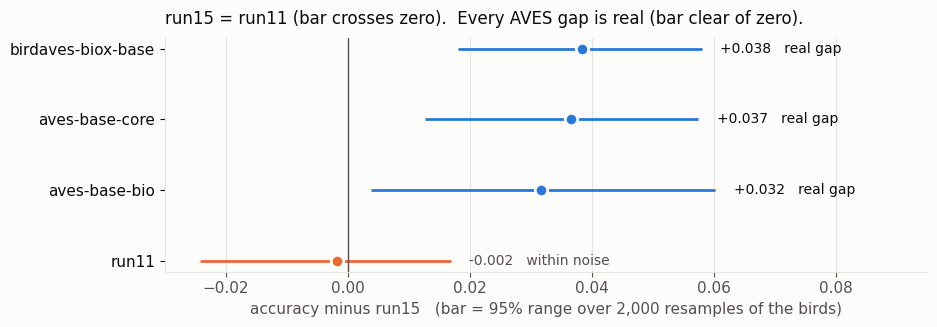

In [3]:
rows = [("run11", "run11"), ("aves-base-bio", "aves-base-bio"),
        ("aves-base-core", "aves-base-core"), ("birdaves-biox-base", "birdaves-biox-base")]
# BOOT stores run15 minus X; flip it so the chart reads "X minus run15" (positive = X is better)
d  = [-BOOT["vs"][k]["delta"] for k, _ in rows]
lo = [-BOOT["vs"][k]["hi"] for k, _ in rows]
hi = [-BOOT["vs"][k]["lo"] for k, _ in rows]

fig, ax = plt.subplots(figsize=(9.5, 3.4))
y = np.arange(len(rows))
for yi, (k, _), a, b, c in zip(y, rows, lo, hi, d):
    col = OURS if k == "run11" else AVES
    ax.hlines(yi, a, b, color=col, lw=2)
    ax.scatter(c, yi, s=80, color=col, zorder=3, edgecolors=SURFACE, linewidths=2)
    real = BOOT["vs"][k]["resolved"]
    ax.text(max(b, 0) + 0.003, yi, f"{c:+.3f}   " + ("real gap" if real else "within noise"),
            va="center", fontsize=10, color=INK if real else INK2)
ax.axvline(0, color=INK2, lw=1)
ax.set_yticks(y); ax.set_yticklabels([n for _, n in rows])
ax.set_xlim(-0.03, 0.095)
ax.set_xlabel("accuracy minus run15   (bar = 95% range over 2,000 resamples of the birds)")
ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
ax.set_title("run15 = run11 (bar crosses zero).  Every AVES gap is real (bar clear of zero).",
             loc="left", fontsize=12, pad=10)
plt.tight_layout(); plt.show()

**Also worth knowing:** `aves-base-bio` — the "AVES" we quoted in every past comparison — is tied
for the *weakest* of the six. So the old headline gap was the most flattering version for us.

---
## 2. The suspects

Our model and AVES are the **exact same architecture** — same 94.37M parameters, same layers. So
the gap has to come from *how* each was trained. Each row is one difference between the two
recipes, and what happened when we changed ours to match.

In [4]:
b = BOOT["vs"]["run11"]
tbl = f"""
| suspect | how we tested it | verdict |
|---|---|---|
| **architecture** | compared parameter counts and weight names | ❌ ruled out — identical model |
| **more / more varied audio** | run15: 116 h → {COMP15['run15']['corpus_hours']:.0f} h, adding general sound (FSD50K) | ❌ ruled out at our compute — {-b['delta']:+.4f}, within noise |
| **bigger label vocabulary** (k=100 → 200) | run15, same run | ❌ ruled out at our compute |
| **better training labels** ("iteration 2") | run12, run13, run14 | ❌ ruled out at our compute — none beat run11 |
| **start from AVES, keep training** (DAPT) | DAPT rounds 1 & 2 | ❌ worse on held-out recordings |
| **total training compute** | *never tested* | ❓ **AVES saw {COMP['comparison']['audio_hours_ratio_aves_over_run11']:.1f}× more audio** |
"""
display(Markdown(tbl))


| suspect | how we tested it | verdict |
|---|---|---|
| **architecture** | compared parameter counts and weight names | ❌ ruled out — identical model |
| **more / more varied audio** | run15: 116 h → 224 h, adding general sound (FSD50K) | ❌ ruled out at our compute — -0.0018, within noise |
| **bigger label vocabulary** (k=100 → 200) | run15, same run | ❌ ruled out at our compute |
| **better training labels** ("iteration 2") | run12, run13, run14 | ❌ ruled out at our compute — none beat run11 |
| **start from AVES, keep training** (DAPT) | DAPT rounds 1 & 2 | ❌ worse on held-out recordings |
| **total training compute** | *never tested* | ❓ **AVES saw 9.3× more audio** |


Notice the pattern in the verdicts: **"at our compute."** Every experiment so far changed *what*
the model learned from while keeping *how much* it learned fixed. The one thing we have never
changed is the amount.

---
## 3. The biggest clue: compute

"Compute" here means **total hours of audio the model processed during training** — corpus size
times how many passes it made. This is the chart that reframes everything:

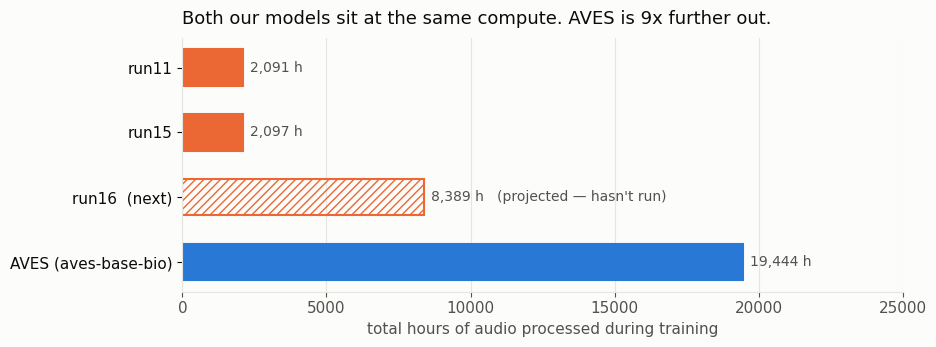

In [5]:
bars = [("run11",              COMP["run11"]["audio_seconds_per_update"] * COMP["run11"]["updates"] / 3600, OURS, False),
        ("run15",              COMP15["run15"]["total_audio_hours"], OURS, False),
        ("run16  (next)",      COMP15["run16_projected"]["total_audio_hours"], OURS, True),
        ("AVES (aves-base-bio)", COMP["aves"]["audio_seconds_per_update"] * COMP["aves"]["updates"] / 3600, AVES, False)]

fig, ax = plt.subplots(figsize=(9.5, 3.6))
y = np.arange(len(bars))[::-1]
for yi, (name, h, col, planned) in zip(y, bars):
    ax.barh(yi, h, height=0.56, color="none" if planned else col, edgecolor=col,
            hatch="////" if planned else None, lw=1.5)
    ax.text(h + 250, yi, f"{h:,.0f} h" + ("   (projected — hasn't run)" if planned else ""),
            va="center", fontsize=10, color=INK2)
ax.set_yticks(y); ax.set_yticklabels([b[0] for b in bars])
ax.set_xlim(0, 25000)
ax.set_xlabel("total hours of audio processed during training")
ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
ax.set_title("Both our models sit at the same compute. AVES is 9x further out.",
             loc="left", fontsize=13, pad=10)
plt.tight_layout(); plt.show()

In [6]:
r11, av, r15 = COMP["run11"], COMP["aves"], COMP15["run15"]
print(f"{'':22}{'run11':>10}{'run15':>10}{'AVES':>10}")
print(f"{'audio per step (s)':22}{r11['audio_seconds_per_update']:>10.1f}{r15['audio_seconds_per_update']:>10.1f}{av['audio_seconds_per_update']:>10.1f}")
print(f"{'training steps':22}{r11['updates']:>10,}{r15['updates']:>10,}{av['updates']:>10,}")
print(f"{'GPUs actually used':22}{r11['world_size']:>10}{r15['world_size_realised']:>10}{av['world_size']:>10}")
print(f"{'gradient accumulation':22}{r11['update_freq']:>10}{1:>10}{av['update_freq']:>10}")

                           run11     run15      AVES
audio per step (s)          80.3      80.5     700.0
training steps            93,750    93,750   100,000
GPUs actually used             1         1         1
gradient accumulation          1         1         8


**Read the last two rows.** AVES used **one GPU** too — it got its much bigger batch by
*accumulating* 8 batches before each update. Same number of steps as us, ~9× the audio per step.

And here's the embarrassing part: every one of our runs **requested four GPUs and used one**. A
setting in the job script (`--ntasks=1`) meant three GPUs sat at 0% the whole time. So the cheapest
possible test of the compute suspect is free: **use the GPUs we're already paying for.** That's
run16 — run15 with that one setting fixed, 4× the audio per step, nothing else changed.

It won't reach AVES (≈43% of the way), but it answers the yes/no question: *does more compute move
the number at all?*

---
## 4. What's next

| # | who | what | why |
|---|---|---|---|
| 1 | **you** | run `ssh -MNf savio-login` in a terminal | the login expired around midday; nothing can reach Savio until it's back |
| 2 | me | 4-GPU smoke test (~15 min) | 4-GPU training has *never* run in this repo — prove the GPUs split the data instead of all doing the same work |
| 3 | me | run16 (~4–5 h) | 4× compute, one change |
| 4 | me | score run16 on the same scoreboard | does it move toward AVES? |
| 5 | — | **decision** | *if it moves:* push toward AVES's full compute (4 GPUs + 2× accumulation ≈ AVES's batch). *If it doesn't:* compute isn't it either, and the remaining difference is AVES's learning-rate schedule. |

---
## Side quest, done: clustering when nobody labelled the data

For bats with no labels: **don't** judge a clustering by how tight its groups are (silhouette etc.
— those rank models *backwards*). Judge it by whether the groups **reappear in individuals you held
out**. Full walkthrough with plots: `04_clustering_without_labels.ipynb`.